In [1]:
!kaggle competitions download -c data-science-bowl-2018

100%|█████████████████████████████████████████| 358M/358M [00:01<00:00, 196MB/s]



In [4]:
import zipfile

# zip_path = "/kaggle/working/data-science-bowl-2018.zip"
zip_path = "/kaggle/working/train/stage1_train.zip"
extract_path = "/kaggle/working/train"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage

In [13]:
base_path = "/kaggle/working/train"
folders = os.listdir(base_path)

In [14]:
results = []

total_images = 0

In [15]:
for folder in folders:

    image_folder = os.path.join(base_path, folder, "images")

    if not os.path.exists(image_folder):
        continue

    for img_file in os.listdir(image_folder):

        image_path = os.path.join(image_folder, img_file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        thresh = threshold_otsu(gray)

        binary = gray > thresh

        distance = ndimage.distance_transform_edt(binary)

        # -----------------------
        # WITHOUT MARKERS
        # -----------------------

        labels_no_marker = watershed(
            -distance,
            mask=binary
        )

        nuclei_no_marker = len(np.unique(labels_no_marker)) - 1


        # -----------------------
        # WITH MARKERS
        # -----------------------

        coords = peak_local_max(
            distance,
            footprint=np.ones((25,25)),
            labels=binary
        )

        mask = np.zeros(distance.shape, dtype=bool)

        mask[tuple(coords.T)] = True

        markers, _ = ndimage.label(mask)

        labels_marker = watershed(
            -distance,
            markers,
            mask=binary
        )

        nuclei_marker = len(np.unique(labels_marker)) - 1


        # -----------------------
        # Over-segmentation difference
        # -----------------------

        over_seg = nuclei_no_marker - nuclei_marker


        results.append([
            nuclei_no_marker,
            nuclei_marker,
            over_seg
        ])

        total_images += 1

        print(f"Processed {total_images} images")

Processed 1 images
Processed 2 images
Processed 3 images
Processed 4 images
Processed 5 images
Processed 6 images
Processed 7 images
Processed 8 images
Processed 9 images
Processed 10 images
Processed 11 images
Processed 12 images
Processed 13 images
Processed 14 images
Processed 15 images
Processed 16 images
Processed 17 images
Processed 18 images
Processed 19 images
Processed 20 images
Processed 21 images
Processed 22 images
Processed 23 images
Processed 24 images
Processed 25 images
Processed 26 images
Processed 27 images
Processed 28 images
Processed 29 images
Processed 30 images
Processed 31 images
Processed 32 images
Processed 33 images
Processed 34 images
Processed 35 images
Processed 36 images
Processed 37 images
Processed 38 images
Processed 39 images
Processed 40 images
Processed 41 images
Processed 42 images
Processed 43 images
Processed 44 images
Processed 45 images
Processed 46 images
Processed 47 images
Processed 48 images
Processed 49 images
Processed 50 images
Processed

In [16]:
results = np.array(results)

without_marker_avg = results[:,0].mean()

with_marker_avg = results[:,1].mean()

overseg_avg = results[:,2].mean()

In [17]:
print("\nFINAL COMPARISON RESULTS")

print("\nTotal images processed:", total_images)

print("\nAverage nuclei count WITHOUT markers:", without_marker_avg)

print("Average nuclei count WITH markers:", with_marker_avg)

print("Average over-segmentation difference:", overseg_avg)


FINAL COMPARISON RESULTS

Total images processed: 670

Average nuclei count WITHOUT markers: 314.8179104477612
Average nuclei count WITH markers: 46.876119402985076
Average over-segmentation difference: 267.9417910447761


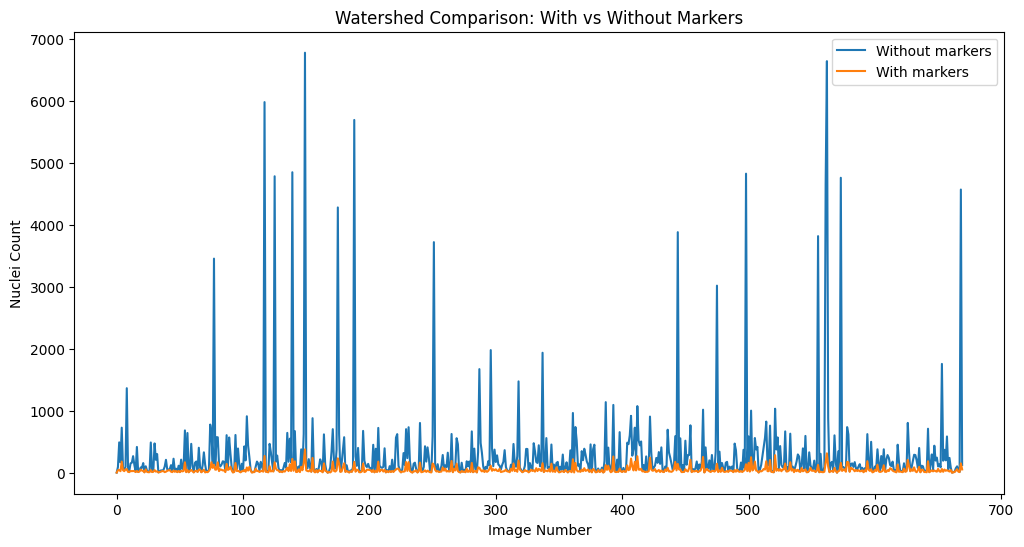

In [18]:
plt.figure(figsize=(12,6))

plt.plot(results[:,0], label="Without markers")

plt.plot(results[:,1], label="With markers")

plt.xlabel("Image Number")

plt.ylabel("Nuclei Count")

plt.title("Watershed Comparison: With vs Without Markers")

plt.legend()

plt.show()